## Outlier Removal using Z-score method

#### Assumption is that the data is normally or near normally distributed  
Now there are two methods trimming and capping So in trimming basically we just remove the data after 3 standard deviations     
but its not a good choice leads to data thining  
In capping, if any value that is below and above the threshold then that value is replaced with threshold value  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day42-outlier-removal-using-zscore/placement.csv')

In [3]:
df.shape

(1000, 3)

In [4]:
df.sample(5)

,cgpa,placement_exam_marks,placed
613,6.66,55.0,1
333,6.74,20.0,1
612,6.14,60.0,1
854,5.83,68.0,1
299,6.75,15.0,1


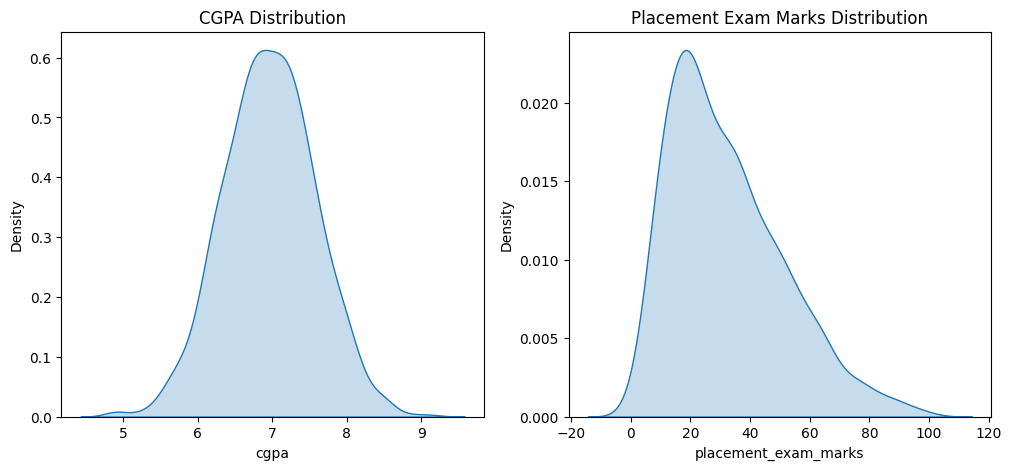

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# first subplot
sns.kdeplot(df['cgpa'], ax=ax[0], fill=True)
ax[0].set_title("CGPA Distribution")

# second subplot
sns.kdeplot(df['placement_exam_marks'], ax=ax[1], fill=True)
ax[1].set_title("Placement Exam Marks Distribution")

plt.show()

In [15]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [17]:
df.describe()['cgpa']

count    1000.000000
mean        6.961240
std         0.615898
min         4.890000
25%         6.550000
50%         6.960000
75%         7.370000
max         9.120000
Name: cgpa, dtype: float64

In [19]:
# finding the boundary values
print("Highest allowed: ",df['cgpa'].mean() + 3*df['cgpa'].std())
print("Lowest allowed: ",df['cgpa'].mean() - 3*df['cgpa'].std())

Highest allowed:  8.808933625397168
Lowest allowed:  5.113546374602832


In [21]:
# Finding outliers
df[(df['cgpa'] > 8.80) | (df['cgpa'] < 5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


### Trimming

In [24]:
new_df = df[(df['cgpa'] < 8.80) | (df['cgpa'] > 5.11)]

In [25]:
new_df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000


### Calculating Z-score

In [26]:
df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean()) / df['cgpa'].std()

In [27]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [28]:
df[df['cgpa_zscore'] > 3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [30]:
df[df['cgpa_zscore'] < -3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [ ]:
# Trimming 
new_df = df[(df['cgpa_zscore'] < 3) & (df['cgpa_zscore'] > -3)]

### Capping

In [31]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [32]:
df['cgpa'] = np.where(df['cgpa'] > upper_limit, upper_limit, 
                      np.where(df['cgpa'] < lower_limit, lower_limit, df['cgpa']))

In [33]:
df.shape

(1000, 4)

In [34]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64